<a href="https://colab.research.google.com/github/NguyenThai365/pka-google-colab-notebook/blob/main/%5BDeepLearning%5D_23010531_Ph%C3%A2n_lo%E1%BA%A1i_%E1%BA%A3nh_040526.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Thiết lập môi trường, seed và kết nối Google Drive**

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import zipfile
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
# Thiết lập seed
SEED = 42
os.environ['seed'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# Kết nối Google Drive lưu Model/Logs
from google.colab import drive
drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/[DL] Phân_loại_ảnh_040526'
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f"Dữ liệu và Model sẽ được lưu tại: {PROJECT_DIR}")

Mounted at /content/drive
Dữ liệu và Model sẽ được lưu tại: /content/drive/MyDrive/[DL] Phân_loại_ảnh_040526


# **Giải nén dữ liệu**

In [ ]:
def extract_data(zip_path, extract_to):
  if os.path.exists(zip_path):
    if not os.path.exists(extract_to):
      print(f"Đang giải nén {zip_path}...")
      with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/dataset/')
      print(f"Đã giải nén xong {zip_path}")
    else:
      print(f"Thư mục {extract_to} đã tồn tại, bỏ qua giải nén.")
  else:
    print(f"LỖI: Không tìm thấy file {zip_path}.")

In [ ]:
# Tạo thư mục chứa dataset
os.makedirs('/content/dataset', exist_ok=True)
# Giải nén
extract_data('/content/training_set.zip', '/content/dataset/training_set')
extract_data('/content/test_set.zip', '/content/dataset/test_set')
# Path sau khi giải nén
train_dir = '/content/dataset/training_set'
test_dir = '/content/dataset/test_set'

Đang giải nén /content/training_set.zip...
Đã giải nén xong /content/training_set.zip
Đang giải nén /content/test_set.zip...
Đã giải nén xong /content/test_set.zip


# **Khám phá dữ liệu (EDA)**

In [ ]:
def explore_data(directory):
  categories = ['cats', 'dogs']
  total_images = 0

  print(f"Dữ liệu: {directory}")
  for category in categories:
    folder_path = os.path.join(directory, category)
    # Bỏ qua nếu thư mục không tồn tại
    if not os.path.exists(folder_path): continue

    images = os.listdir(folder_path)
    total_images += len(images)
    print(f"Số lượng ảnh {category}: {len(images)}")

    if len(images) > 0:
      sample_img_path = os.path.join(folder_path, images[0])
      img = cv2.imread(sample_img_path)
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Chuyển hệ màu OpenCV sang RGB
      print(f"Kích thước 1 ảnh mẫu của {category} (height, width, channels): {img.shape}")

  print(f"Tổng số ảnh: {total_images}\n")

In [ ]:
explore_data(train_dir)

Dữ liệu: /content/dataset/training_set
Số lượng ảnh cats: 4000
Kích thước 1 ảnh mẫu của cats (height, width, channels): (375, 499, 3)
Số lượng ảnh dogs: 4000
Kích thước 1 ảnh mẫu của dogs (height, width, channels): (375, 499, 3)
Tổng số ảnh: 8000



In [ ]:
explore_data(test_dir)

Dữ liệu: /content/dataset/test_set
Số lượng ảnh cats: 1000
Kích thước 1 ảnh mẫu của cats (height, width, channels): (240, 319, 3)
Số lượng ảnh dogs: 1000
Kích thước 1 ảnh mẫu của dogs (height, width, channels): (375, 499, 3)
Tổng số ảnh: 2000



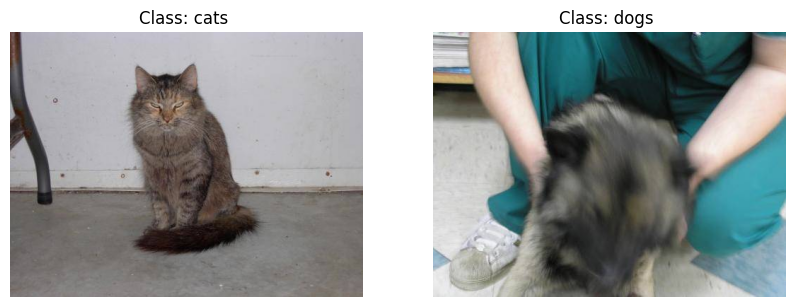

In [ ]:
plt.figure(figsize=(10, 5))
for i, category in enumerate(['cats', 'dogs']):
  folder_path = os.path.join(train_dir, category)
  if os.path.exists(folder_path):
    img_name = os.listdir(folder_path)[0]
    img_path = os.path.join(folder_path, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 2, i+1)
    plt.imshow(img)
    plt.title(f"Class: {category} ")
    plt.axis('off')
plt.show()

# **Tiền xử lý dữ liệu**

In [ ]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

In [ ]:
# Rescale pixel về 0-1 và áp dụng Augmentation (chỉ áp dụng cho tập train)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
print("Đang load tập training")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED
)

Đang load tập training
Found 8000 images belonging to 2 classes.


In [ ]:
print("Đang load tập test")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    seed=SEED
)

Đang load tập test
Found 2000 images belonging to 2 classes.


In [ ]:
class_names = train_generator.class_indices
print("Nhãn:", class_names)

Nhãn: {'cats': 0, 'dogs': 1}


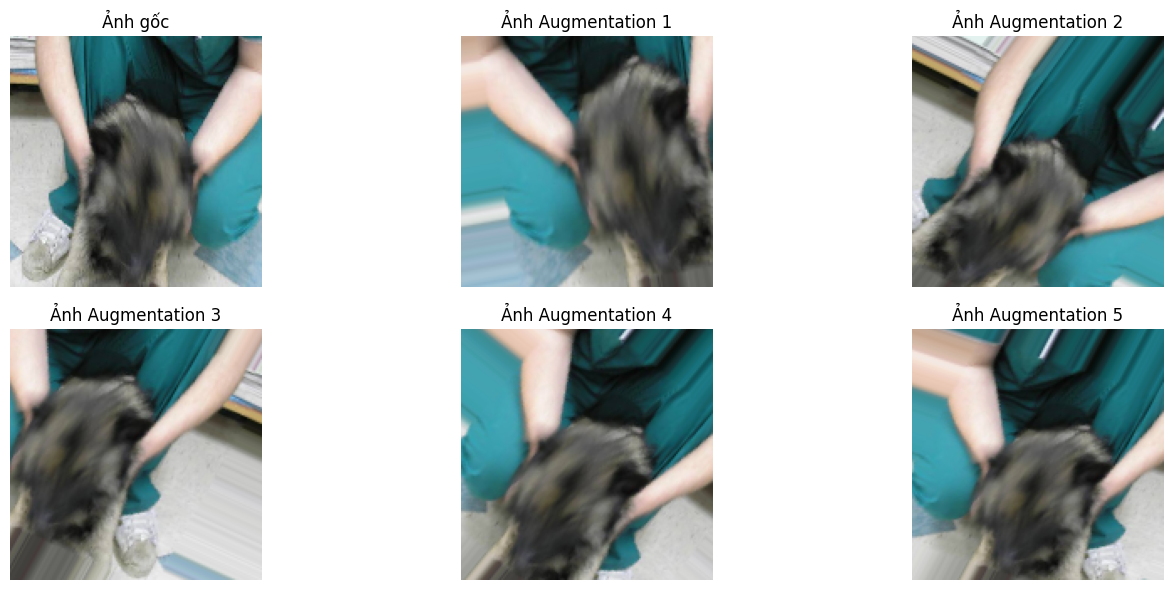

In [ ]:
sample_folder = os.path.join(train_dir, 'dogs')
sample_img_name = os.listdir(sample_folder)[0]
sample_img_path = os.path.join(sample_folder, sample_img_name)

# Load ảnh và chuyển về mảng numpy
img = image.load_img(sample_img_path, target_size=IMG_SIZE)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

# Hiển thị ảnh
plt.figure(figsize=(15, 6))
plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title("Ảnh gốc")
plt.axis('off')

i = 2
for batch in train_datagen.flow(x, batch_size=1, seed=SEED):
  plt.subplot(2, 3, i)
  plt.imshow(batch[0])
  plt.title(f"Ảnh Augmentation {i-1}")
  plt.axis('off')
  i += 1
  if i > 6:
    break

plt.tight_layout()
plt.show()

# **Build và train model**

In [ ]:
MODEL_PATH = os.path.join(PROJECT_DIR, 'cnn_dog_cat_model.h5')
LOG_PATH = os.path.join(PROJECT_DIR, 'training_log.csv')

In [ ]:
def build_model():
  model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3), kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
  ])

  model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])
  return model

In [ ]:
if os.path.exists(MODEL_PATH):
  print("Đã tìm thấy model. Đang tải model.")
  model = load_model(MODEL_PATH)

  if os.path.exists(LOG_PATH):
    logs = pd.read_csv(LOG_PATH)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(logs['accuracy'], label='Train Acc'); plt.plot(logs['val_accuracy'], label='Val Acc')
    plt.title('Accuracy'); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(logs['loss'], label='Train Loss'); plt.plot(logs['val_loss'], label='Val Loss')
    plt.title('Loss'); plt.legend()
    plt.show()
else:
  print("Chưa có model. Bắt đầu quá trình xây dựng và huấn luyện.")
  model = build_model()
  model.summary()

  # Callbacks để lưu log và lưu model tốt nhất. Đồng thời thiết lập early stopping
  checkpoint = ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1)
  csv_logger = CSVLogger(LOG_PATH, append=False)
  early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
  )
  reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
  )

  # train model
  history = model.fit(
      train_generator,
      epochs=50,
      validation_data=test_generator,
      callbacks=[checkpoint, csv_logger, early_stopping, reduce_lr]
  )

  # Plot sau khi train
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs_range = range(len(acc))
  plt.figure(figsize=(12, 4))
  plt.subplot(1, 2, 1)
  plt.plot(epochs_range, acc, label='Train Acc')
  plt.plot(epochs_range, val_acc, label='Val Acc')
  plt.title('Accuracy')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(epochs_range, loss, label='Train Loss')
  plt.plot(epochs_range, val_loss, label='Val Loss')
  plt.title('Loss')
  plt.legend()
  plt.show()

Chưa có model. Bắt đầu quá trình xây dựng và huấn luyện.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,297 (434.75 KB)

 Trainable params: 110,593 (432.00 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/50
  4/250 ━━━━━━━━━━━━━━━━━━━━ 12:49 3s/step - accuracy: 0.5703 - loss: 1.1194

KeyboardInterrupt: 

In [ ]:
model.summary()

# **Đánh giá model**

In [ ]:
print("Đang dự đoán trên tập Test...")
test_generator.reset()

# Dự đoán
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).reshape(-1)
y_true = test_generator.classes

In [ ]:
print(classification_report(y_true, y_pred, target_names=['Cats (0)', 'Dogs (1)']))

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cats', 'Dogs'], yticklabels=['Cats', 'Dogs'])
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.title('Confusion Matrix')
plt.show()